In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import cMonocularMeasure
from cmonocularcal import CMonocularCalibration

In [2]:
#多张图片标定得到相机的内参与畸变向量
images_path = r'C:\Users\hp\Desktop\mm\\3'
mycc = CMonocularCalibration()
mycc.monocular_set_calibration_images(images_path, 'monocular.npy', False, 7, 3648, 5472, [7,7], 5.0, mode='circle')
mycc.monocular_calibration('monocular.npy', True)
mycc.monocular_print()

Your calibration file was not detected
有效的标定板数量:  16

 Internal matrix is: 
 [[6.87409870e+03 0.00000000e+00 2.72994873e+03]
 [0.00000000e+00 6.87316947e+03 1.81689630e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]] 

Distortion vector is: 
 [[-0.07191442  0.16638227  0.00089058  0.00034821 -0.00753883]] 



In [3]:
mycmm = cMonocularMeasure.MonocularMeasure()
# mycmm.read_calibration_file(r'C:\Users\hp\Desktop\mm\\2', c_file_name='monocular.npy')
mycmm.read_calibration_tiff(r'C:\Users\hp\Desktop\mm\\3')
mycmm.params_print()


 Internal matrix is: 
 [[6.8740986e+03 0.0000000e+00 2.7299487e+03]
 [0.0000000e+00 6.8731694e+03 1.8168962e+03]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]] 

Distortion vector is: 
 [[-0.07191442  0.16638227  0.00089058  0.00034821 -0.00753883]] 



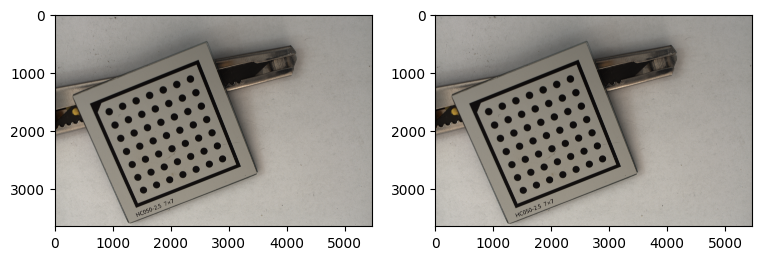

In [4]:
imgpath = 'C:\\Users\\hp\\Desktop\\mm\\3\\Image_20221230152530503.bmp' #yl
src_img = cv2.imread(imgpath, 1)
mycmm.calc_UndistortRectifyMap(src_img)
remaped_img = mycmm.img_remap(src_img)
plt.figure(figsize=(9,4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(remaped_img, cv2.COLOR_BGR2RGB))

In [5]:
#测距用的单张标定图像，该图不需要畸变矫正
#对称圆标定板上圆的行数、列数
monocular_circleSize = [7,7]
monocular_circleCellLen = 5.0 #mm，圆心距
mode = 'circle'

# 得到该标定图像中标定板上的圆心实际坐标与对应像素坐标
ret_l, world_points, pixel_points = mycmm.findCornersAndWorldPoints(singleImgPath=src_img, 
                                                chessSize=monocular_circleSize, 
                                                chessCellLen=monocular_circleCellLen, mode=mode)
A = mycmm._monocularParameters["cameraMatrix"]
distCoeff = mycmm._monocularParameters["distCoeffs"]

checked!!!!!!!!!


In [6]:
pixel_points = mycmm.points_remap(pixel_points) # 映射稀疏点，去掉畸变的影响

In [7]:
# pnp求解外参数矩阵
retvel, rvec, tvec = cv2.solvePnP(world_points, pixel_points, cameraMatrix=A, distCoeffs=None)
R_w2c, _jaconbin = cv2.Rodrigues(rvec)
print(retvel)
print(R_w2c.shape)
print(tvec.shape)
print(R_w2c[0])

True
(3, 3)
(3, 1)
[ 0.92910232  0.36768485 -0.03970812]


In [8]:
# 计算重投影误差
re_project_all = mycmm.world_to_pixel(world_points.T, A, R_w2c, tvec)
re_project_all = re_project_all.T[:,0:2]
diff_re = re_project_all - pixel_points
re_err = 0.0
for _vec in diff_re:
    re_err = re_err + np.sqrt(np.sum(_vec*_vec))
print(world_points.shape, ' ', re_err)

re_project_all = mycmm.pixel_to_world(pixel_points.T, A, R_w2c, tvec)
re_project_all = re_project_all.T
re_project_all[:,2]=0
diff_re = re_project_all - world_points
re_err = 0.0
for _vec in diff_re:
    re_err = re_err + np.sqrt(np.sum(_vec*_vec))
print(pixel_points.shape, ' ', re_err)

(49, 3)   7.347731509887061
(49, 2)   0.14836502308025956


In [9]:
index = 0
world_p0 = np.concatenate((world_points[index][..., np.newaxis], world_points[index+1][..., np.newaxis]), axis=1)

print(world_p0.shape, '\n', world_p0)
pixel_p0 = np.concatenate((pixel_points[index][..., np.newaxis], pixel_points[index+1][..., np.newaxis]), axis=1)
print(pixel_p0.shape, '\n', pixel_p0, '\n')

# 从世界坐标到像素坐标
re_project_pixel = mycmm.world_to_pixel(world_p0, A, R_w2c, tvec)
print(re_project_pixel)

# 从像素坐标到世界坐标
re_project_world = mycmm.pixel_to_world(pixel_p0, A, R_w2c, tvec)
print(re_project_world)


(3, 2) 
 [[0. 5.]
 [0. 0.]
 [0. 0.]]
(2, 2) 
 [[ 924.28076 1157.7377 ]
 [1679.5309  1586.0269 ]] 

[[9.24054379e+02 1.15774803e+03]
 [1.67936404e+03 1.58601280e+03]
 [1.00000000e+00 1.00000000e+00]]
[[2.7890368e-03 4.9996963e+00]
 [4.7021862e-03 1.7854442e-04]
 [1.0000000e+00 1.0000000e+00]]


[[2.24189096e+03 2.84043156e+03 2.48193588e+03 2.22016907e+03]
 [2.22668328e+03 1.98886681e+03 2.80595641e+03 2.36354645e+03]
 [1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00]]


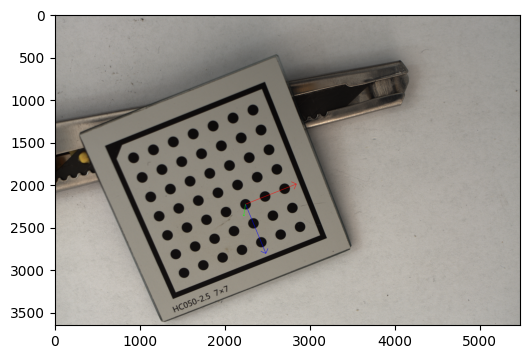

In [10]:
# 画一个坐标系
_src_copy = remaped_img.copy()
w_points = np.array([[20,20,0], [33,20,0], [20,33,0], [20,20,-13]], dtype=np.float32) # 行向量表示
w_points = w_points.T # 列向量表示
pix_res = mycmm.world_to_pixel(w_points, A, R_w2c, tvec)
print(pix_res)
# 绘制线段
po = (int(pix_res[0][0]), int(pix_res[1][0]))
px = (int(pix_res[0][1]), int(pix_res[1][1]))
py = (int(pix_res[0][2]), int(pix_res[1][2]))
pz = (int(pix_res[0][3]), int(pix_res[1][3]))

cv2.arrowedLine(_src_copy, po, px, (0,0,255), thickness=4)
cv2.arrowedLine(_src_copy, po, py, (255,0,0), thickness=4)
cv2.arrowedLine(_src_copy, po, pz, (0,255,0), thickness=4)
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(_src_copy, cv2.COLOR_BGR2RGB))